# 1. Basic Machine Learning Pipeline for a DSS Thesis 

In this tutorial, we sketch a basic ML learning pipeline to solve a toy data science problem. The idea is to first review what you have learned in this program, and set a minimum standards for the analysis in your thesis. 

A basic ML pipeline in general can include the following steps:

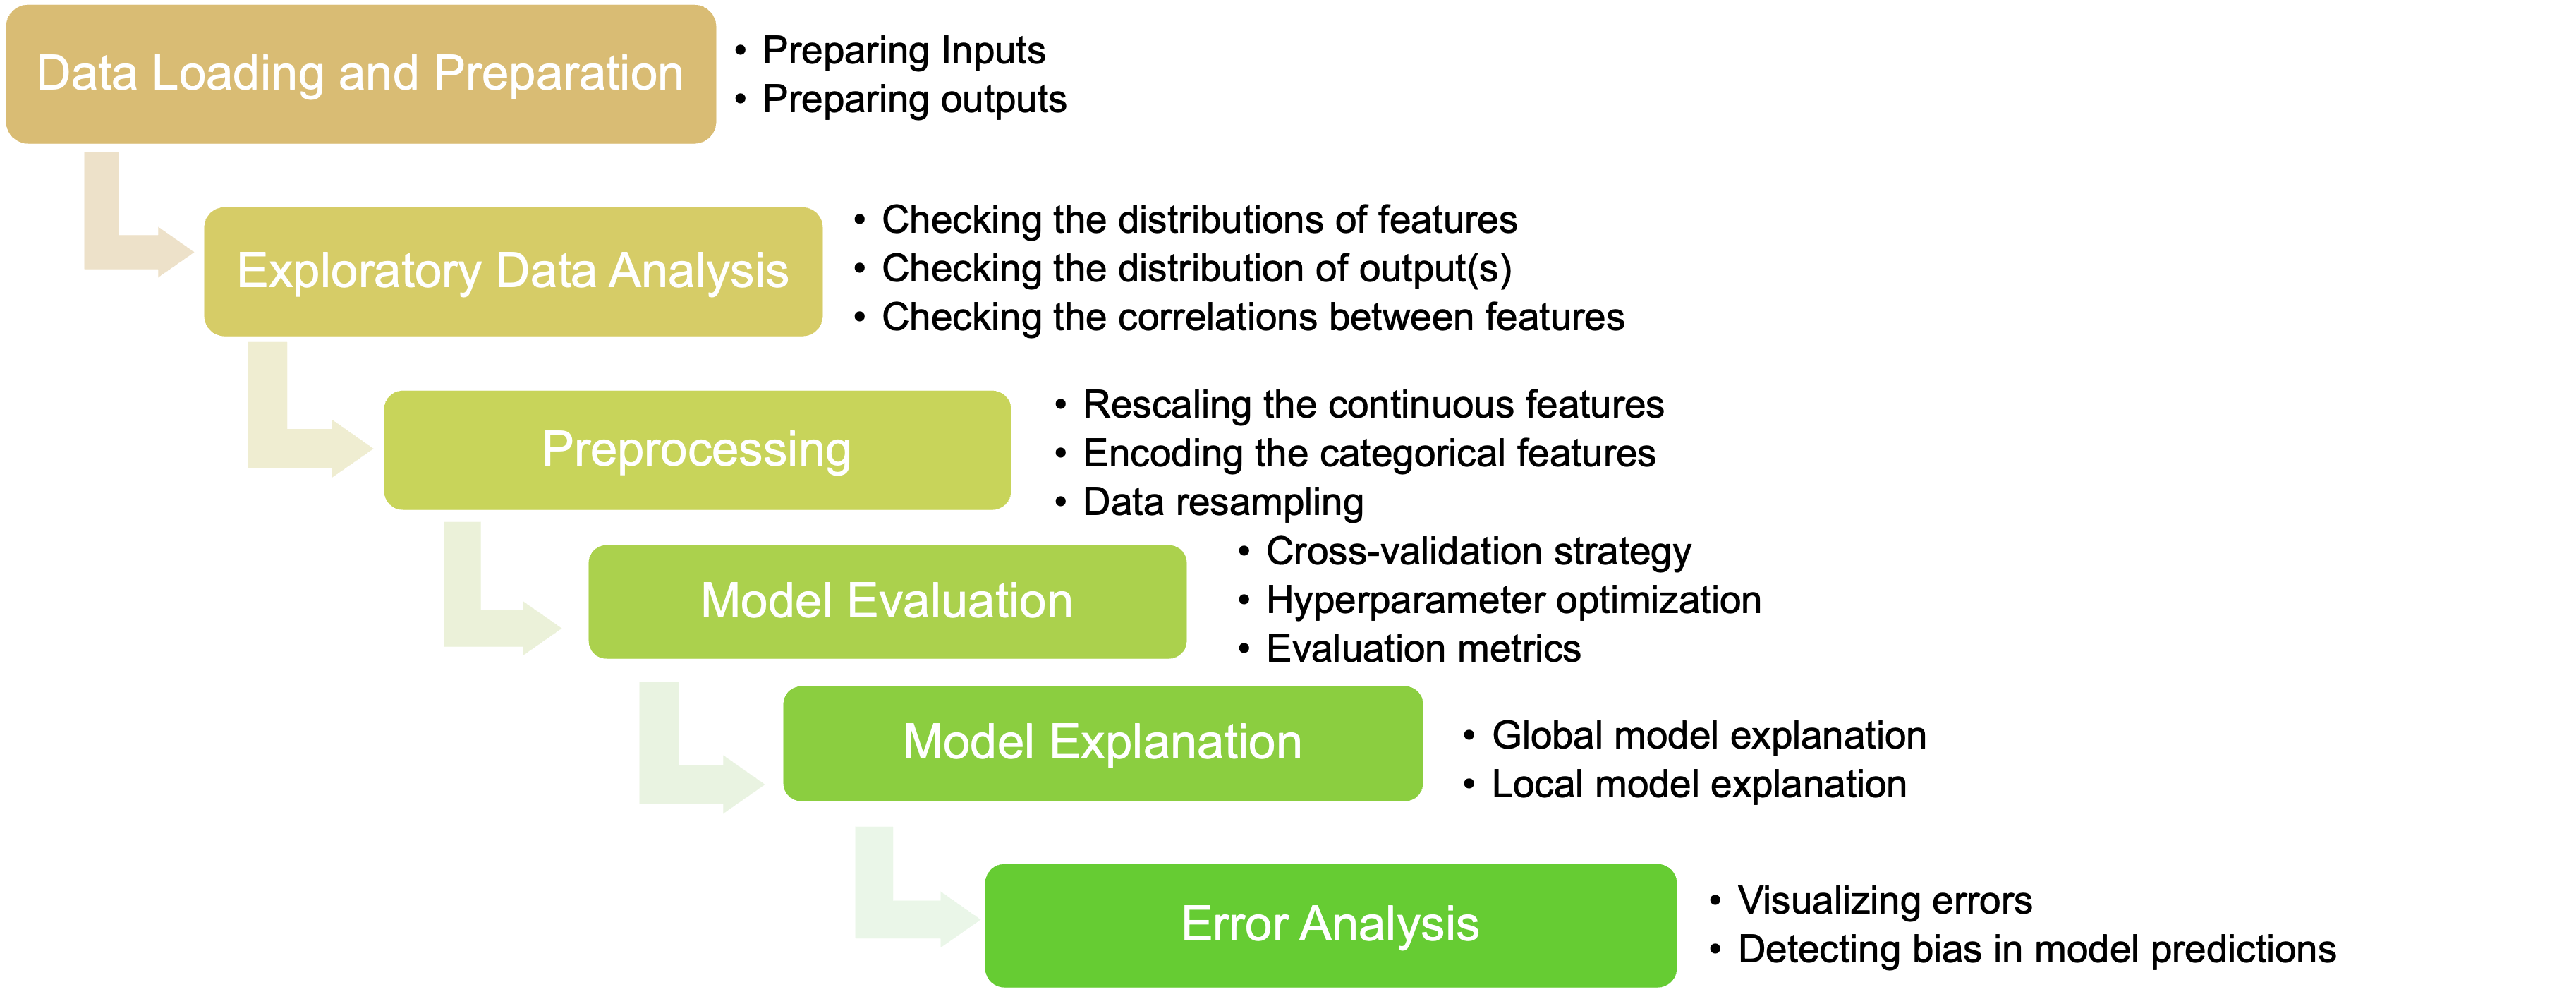

## 1.1 The Dataset

To this end, we use a toy dataset from scikit-learn: the Diabetes dataset (https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset). The "Diabetes" dataset contains 10 features namely:

* age: age in years
* sex
* bmi: body mass index
* bp: average blood pressure
* s1: tc, total serum cholesterol
* s2: ldl, low-density lipoproteins
* s3: hdl, high-density lipoproteins
* s4: tch, total cholesterol / HDL
* s5: ltg, possibly log of serum triglycerides level
* s6: glu, blood sugar level

The aim is to use an ML model to predict if the disease is progressive (i.e. high risk patient) or not (i.e. low risk patient) one year after the measurement.

## 1.2 Research Question and Sub-questions

In data science, it is useful to distinguish between a high-level research question and more technical subquestions. The main research question should be understandable without specialized knowledge and reflect the broader societal relevance of the problem. Subquestions then translate this goal into concrete, testable analyses using data and machine learning methods.

The main research question should:
- define why the work matters
- communicate the goal to non-experts
- anchor the analysis in societal relevance
- remain meaningful even if the methods change

Therefore, the main question should: avoid technical jargon (e.g. “ROC-AUC”, “nested CV”, “elastic net”), focus on the problem, not the solution, be understandable by clinicians, policymakers, or the general public. An example main question for our problem could be like:

- "Can machine learning models trained on routine clinical measurements predict one-year diabetes disease progression and distinguish between high-risk and low-risk patients?"

Subquestions are where you make the main question:
- empirical and testable, 
- translate it into measurable components, 
- and justify methodological choices.

The subquestions must be empirical questions, with the following characteristics: 

- Data-driven: The question can be answered using data (existing or newly collected).
- Operationalizable: Variables can be clearly defined and measured. Inputs, outputs, and evaluation criteria are explicit.
- Testable: The question leads to hypotheses or models whose performance can be assessed.
- Method-dependent: The answer depends on the data and methods used (e.g., choice of model, features, metrics).
- Revisable: Conclusions may change with more data, better models, or different assumptions.

| Question type | Example                                                | Empirical?   | Why                                        |
| ------------- | ------------------------------------------------------ | ------------ | ------------------------------------------ |
| Predictive    | *Can ML models predict one-year diabetes progression?* | Yes          | Answered by training and evaluating models |                  |
| Comparative   | *Which model performs best for risk stratification?*   | Yes          | Compared using metrics                     |
| Causal        | *Does BMI cause diabetes progression?*                 | Not directly | Requires causal assumptions beyond data    |
| Normative     | *Should ML be used in clinical decision-making?*       | No           | Value-based judgment                       |



To this end, we try to answer the following sub-questions in this tutorial:

1) "How do different machine learning models compare in their ability to predict one-year diabetes disease progression and to support risk stratification?"
2) "Which clinical features contribute most strongly to the prediction of diabetes disease progression and risk stratification?"
3) "Does the predictive performance of the machine learning models differ across patient subgroups, such as sex, indicating potential bias (or fairness concerns)?"


## 1.3 Societal Relevance

- **Early Intervention & Prevention of Complications:** Identifying individuals at high risk for diabetes allows for early intervention, which can include lifestyle changes and preventive care. Early intervention can significantly reduce the risk of developing diabetes. Furthermore, progressive diabetes in high-risk patients can cause serious health complications like heart disease, kidney failure, and blindness. Early detection and management can prevent or delay these complications.
- **Resource Management:** Classifying patients helps healthcare providers to prioritize care and allocate resources more effectively. High-risk patients may require more frequent monitoring and aggressive treatment.
- **Personalized Treatment:** Knowing a patient's risk level allows for more personalized treatment plans. For high-risk patients, more rigorous treatment strategies might be necessary.
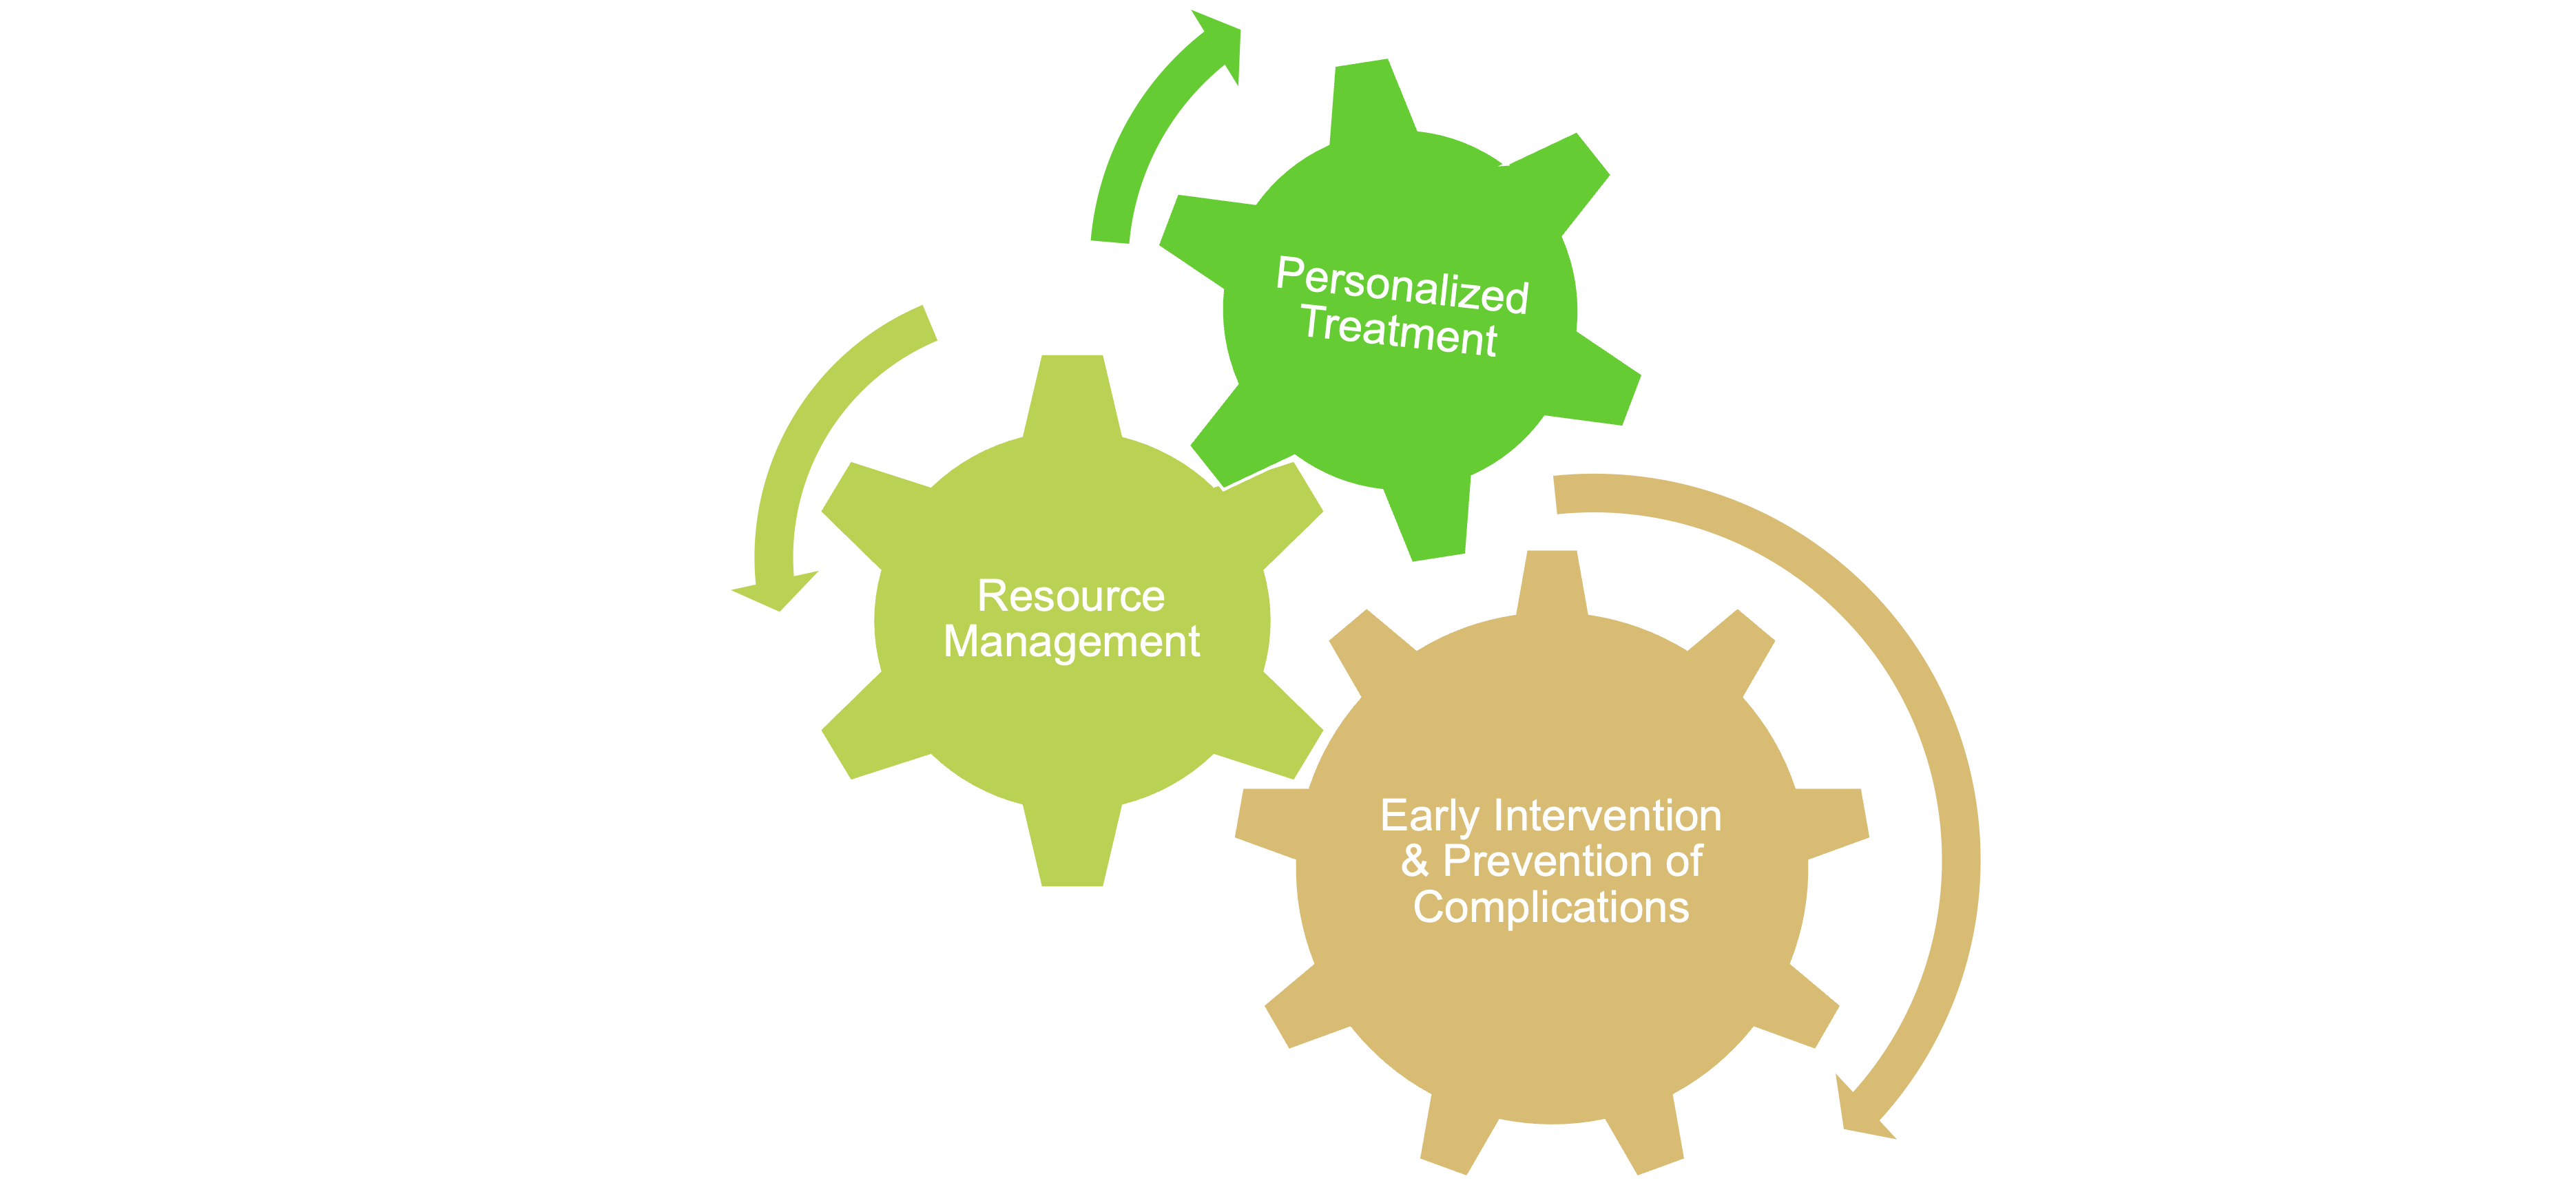



## 1.4 The Needed Packages 

In this project, we use Numpy, Pandas, Matplotlib, and scikit-learn for implementation of the data. processing pipeline .

In [ ]:
# Importing Packages

######## Data Processing Packages ########
import numpy as np
import pandas as pd

######## Visualization Packages ########
import seaborn as sns
import matplotlib.pyplot as plt

######## Data and Preprocessing Modules ########
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

##### Machine Learning Models ########
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

##### Model Evaluation Modules ########
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

## 1.5 Loading the Data and Early Data Inspection

Here, we first load the dataset and then cast the feature matrix and target vectors into Pandas dataframes. We can use the `head` function from Pandas to inspect the feature matrix:

In [ ]:
# Load the dataset
data = load_diabetes(scaled=False)
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)
feature_names = data.feature_names

X.head()

In [ ]:
y.head()

In [ ]:
# 1. Initial Data Exploration:
print(X.head())
print("\nShape of the dataset:", X.shape)
print("\nData types of each column:")
print(X.dtypes)
print("\nMissing values in each column:")
print(X.isnull().sum())

The `describe` function can be used to calculate some statistics on the features. The derived statistics can give us some general information about the features. For example, what are the ranges of different features (given the mean, min, and max), or whether we have some outliears in the data (checking the difference between the mean and min/max). However, extracting high-level information by eyeballing vast amount of numbers is not always straightforward. This is why we usually use data visualization.

In [ ]:
# 2. Summary Statistics:
print("\nSummary statistics for numerical columns:")
print(X.describe())

Distinguishing between continuous and categorical features is a crucial step in building a machine learning pipeline, as different feature types require different preprocessing strategies (for example, scaling for continuous variables and encoding for categorical variables). In this tutorial, this distinction is made explicitly to illustrate how feature semantics guide preprocessing choices. As an example, the sex variable is converted to a categorical data type, since it represents a nominal attribute despite being numerically encoded. The input features are then separated into continuous and categorical variables based on their data types.

In [ ]:

# Identify numerical and categorical columns
X['sex'] = X['sex'].astype('object') # just for demonstration I change the datatype of sex into object
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object','bool']).columns
print("Continuous features: ", numerical_cols.values)
print("Categorical features: ", categorical_cols.values)

We can do the same for the outcome measure.

In [ ]:
y.describe()

The outcome measure in the Diabetes dataset is a continuous variable reflecting disease progression one year after the baseline measurement. In this tutorial, both regression and classification approaches are demonstrated. While the regression task directly models the continuous outcome, a classification task is constructed by transforming this outcome into binary risk groups.

To this end, the continuous outcome is thresholded using its mean value, resulting in two classes: low-risk patients (label 0), with outcome values below the mean, and high-risk patients (label 1), with outcome values at or above the mean. This binarization enables illustration of classification methods while remaining grounded in the original regression problem.

In [ ]:
# From continuous to binary outcomes 
threshold = np.mean(y)  # 
y_binary = (y >= threshold).astype(int)
y_binary.head()

## 1.6 Exploratory Data Analysis

The purpose of Exploratory Data Analysis (EDA) is multi-fold:

- **Understand Data Characteristics**: EDA helps in getting a feel for the data, understanding its structure, and recognizing patterns or anomalies. This includes identifying data types, checking data dimensions, and recognizing data quality issues such as the presence of missing or outlier values.

- **Summarize Main Features:** It involves summarizing the main characteristics of the dataset. This includes using statistics for central tendency (like mean, median) and dispersion (like standard deviation, interquartile ranges) and visual tools like histograms, box plots, and scatter plots.

- **Discover Patterns and Relationships:** EDA involves looking for correlations, trends, and relationships between variables, which can be vital for model building.

- **Facilitate Communication:** Visualizations created during EDA are valuable for communicating findings and insights to non-technical stakeholders, making it easier to explain complex data concepts.



### 1.6.1 Histograms of Features

Histograms are a fundamental tool in Exploratory Data Analysis (EDA) and they serve several key purposes, especially when examining the features of a dataset:

- **Understanding Distributions:** Histograms provide a visual representation of the distribution of a numerical variable. They show how often each range of values (bins) occurs in the dataset. This helps in understanding whether the data is normally distributed, skewed, has multiple modes (peaks), or other distribution characteristics.

- **Identifying Skewness and Symmetry:** By visually inspecting histograms, you can identify if the data for a feature is symmetrically distributed, skewed to the left (negatively skewed), or skewed to the right (positively skewed). This can have implications for certain types of statistical analysis and model selection.

- **Detecting Outliers and Anomalies:** Histograms can help in spotting outliers or anomalies in data. Unusual spikes or gaps in the histogram may indicate outliers or data integrity issues that need further investigation.

- **Guiding Data Transformation:** Based on the shape of the histogram, you might decide to transform the data to fit a certain distribution (e.g., using a logarithmic transformation to handle right-skewed data) which can be beneficial for certain types of statistical analyses or machine learning models.

- **Facilitating Assumption Checking:** For certain statistical tests and models, there are assumptions about the distribution of the data (e.g., normality for linear regression). Histograms can be used to check these assumptions.

We could further overlay a normal curve on top of histograms to check the normality of continuous features. We can use the matplotlib tools such as `subplots`, `hist` and `plot`. In this case, we can set the `density=True` option to plot the density (rather than the bin count) of features. Also check out how advanced Numpy concepts such as broadcasting are used to calculate the normal curves. 

Based on this visualization, it seems in most cased the distribution of features is skewed and deviates from a perfect normal. We should consider this when preprocessing our data.

In [ ]:
# We first drop Sex which is a categorical feature
fig, ax = plt.subplots(3, 3, figsize=(14,10))
ax = ax.flatten()

bins = np.arange(30)

# Loop through each feature to create a histogram with a normal distribution overlay

for c, column in enumerate(numerical_cols):
    # Calculate the mean and standard deviation
    mu, sigma = X[column].mean(), X[column].std()
    
    # Set up the histogram
    count, bins, ignored = ax[c].hist(X[column], 30, density=True, alpha=0.6, color='g')


    # Add a line for the normal distribution
    ax[c].plot(bins, 1/(sigma * np.sqrt(2 * np.pi)) * np.exp(-(bins - mu)**2 / (2 * sigma**2)), linewidth=2, color='r')

    ax[c].set_title(f'Feature: {column}')
    ax[c].set_xlabel(column)
    ax[c].set_ylabel('Density')


plt.tight_layout()
plt.savefig('Feature_hists_norm.pdf', dpi=300)

### 1.6.2 Boxplot of Features

Another useful visualization technique for examining feature distibution is boxplot. Boxplots are useful for:

- **Summarizing Data Distribution:** A boxplot provides a five-number summary of a dataset: minimum, first quartile (Q1), median (second quartile, Q2), third quartile (Q3), and maximum. This summary gives a quick overview of the distribution and central tendency of the data.

- **Identifying Outliers:** One of the key uses of a boxplot is to visually identify outliers. Points that lie outside the 'whiskers' of the boxplot (typically 1.5 times the interquartile range above the third quartile or below the first quartile) are often considered outliers. This can be crucial for deciding whether to investigate further or treat these data points.

- **Comparing Distributions Across Groups:** Boxplots are particularly useful for comparing the distributions of a variable across different categories or groups. For instance, you can compare the distribution of a variable across different levels of a categorical feature or between different subgroups in your data.

- **Detecting Skewness:** The symmetry or asymmetry of the boxplot can indicate skewness in the data. A boxplot where the median is not centered (closer to the bottom or top) can indicate a skewed distribution.

- **Understanding Variability:** The spread of the boxplot, especially the length of the 'whiskers' and the size of the interquartile range (the box), provides a visual indication of the variability or dispersion in the data.

- **Facilitating Decision-Making in Preprocessing:** Insights from boxplots can guide data preprocessing decisions, such as the need for data normalization, outlier treatment, or feature transformation.

We can use some simple tricks to make the boxplot more informative and visually appealing:

In [ ]:
# Enhanced Box plots
plt.figure(figsize=(15, 7))

# Create the boxplot with additional styling
boxprops = dict(linestyle='-', linewidth=2, color='navy')
medianprops = dict(linestyle='-', linewidth=2, color='firebrick')
whiskerprops = dict(linestyle='--', linewidth=2, color='black')
capprops = dict(linestyle='-', linewidth=2, color='grey')

boxplot = plt.boxplot(X[numerical_cols], labels=numerical_cols, notch=True, patch_artist=True, 
                      boxprops=boxprops, medianprops=medianprops, 
                      whiskerprops=whiskerprops, capprops=capprops)

# Adding grid, title and labels
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7, axis='y')
plt.title('Feature Distribution - Boxplot', fontsize=18, fontweight='bold')
plt.xlabel('Features', fontsize=16)
plt.ylabel('Values', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Remove spines
for spine in plt.gca().spines.values():
    spine.set_visible(False)

# Save the plot
plt.savefig('Feature_boxplot.pdf', dpi=300)



### 1.6.3 Visualizing Feature Correlations using Heatmaps 

Correlation analysis on features is a fundamental aspect of Exploratory Data Analysis (EDA) in data science and statistics, with significant importance for several reasons:

- **Understanding Relationships**: It helps in understanding the relationship between different features in the dataset. Correlation coefficients quantify the degree to which two variables are related.

- **Feature Selection**: Correlation analysis is crucial in feature selection for machine learning models. Features that are highly correlated with the target variable (mind that this step must be done only on the training set) may be good predictors. Conversely, features with little or no correlation might not be useful and could be dropped to simplify the model.

- **Multicollinearity Detection**: In linear regression models, multicollinearity (high correlation between independent variables) can distort the model's estimates and affect the interpretability of the model. Identifying and addressing multicollinearity is essential for building accurate and reliable models.

A heatmap is an effective graphical representation of data where the individual values contained in a matrix are represented as colors. It's particularly well-suited for visualizing correlation matrices. Representing Correlation Coefficients: In a heatmap for correlation analysis, each cell shows the correlation coefficient between two variables, with varying colors indicating the strength and direction of the correlation (e.g., from strong negative to strong positive).

We can use `imshow` function from matplotlib to creat heatmaps:

In [ ]:
correlation_matrix = X[numerical_cols].corr()

plt.figure(figsize=(12, 8))
plt.imshow(correlation_matrix, cmap='coolwarm', vmax=1, vmin=-1)
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title('Feature Correlation Matrix')
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        text = plt.text(j, i, np.around(correlation_matrix.iloc[i, j], decimals=2),
                        ha="center", va="center", color="w")
plt.savefig('Correlation_heatmap_before.pdf', dpi=300)


### 1.6.4 Target Class Distribution in Classification

We can use the barplot to visualize the target class distribution. In this case, it seems we have a completely balanced setting.

Please note that how we use the Matplotlib tools to make our barplot nicer.

In [ ]:
# we can effectively use our Numpy knowledge in counting the number samples in each class
class_counts = [np.sum(y_binary == 0), np.sum(y_binary == 1)]
class_labels = ['Low Risk', 'High Risk']

# Enhanced Bar Plot
plt.figure(figsize=(6, 4))
bars = plt.bar(class_labels, class_counts, color=['skyblue', 'salmon'], width=0.75)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7, axis='y')

# Adding title and labels with styling
plt.title('Distribution of Target Classes', fontsize=16, fontweight='bold')
plt.xlabel('Classes', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Adding value annotations on each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval-100, int(yval), 
             ha='center', fontweight='bold', fontsize=16)

# Remove spines
for spine in plt.gca().spines.values():
    spine.set_visible(False)

# Show the plot
plt.tight_layout()
plt.savefig('Class_dist_barplot.pdf', dpi=300)


### 1.6.5 Target Distribution in Regression

Pair plots provide a compact visual overview of pairwise relationships between continuous variables. In the context of a regression problem, including the continuous target variable alongside the input features allows simultaneous inspection of the target distribution and its relationships with individual predictors. Such visualizations help identify potential linear or non-linear associations, differences in scale, skewness, and outliers, all of which can influence model choice, preprocessing decisions (e.g., scaling or transformation), and expected model performance. 

In [ ]:
sns.set_context("notebook", font_scale=1.5)

# Combine continuous features and continuous target
plot_data = X[numerical_cols].copy()
plot_data['target'] = y

# Pair plot (lower triangle only)
sns.pairplot(
    plot_data,
    corner=True,
    diag_kind='hist'
)

plt.suptitle(
    "Pairwise relationships between continuous features\n"
    "and diabetes disease progression",
    y=1.02
)
plt.show()


## 1.7 Data Preprocessing Pipeline

Now and after the EDA, we have a better understanding of our features and target variable. It is time to use our gained knowledge for more effective preprocessing of data. 

Different feature types require different preprocessing strategies before they can be used in machine learning models. Continuous features are typically scaled to ensure comparable ranges, while categorical features must be encoded into a numerical representation.

### 1.7.1 Preprocessing steps depend on data and model types

**Common Pitfall:** Using the same preprocessing pipeline for all features and models.

Preprocessing steps such as feature scaling and categorical encoding are not universally required, but depend on the assumptions and mechanics of the chosen machine learning model. Distance-based and weight-based models typically require scaled inputs and numerical encodings, whereas tree-based models are largely invariant to feature scaling and can handle categorical features differently. 

| Model family                              | Feature scaling needed? | Categorical encoding needed? | Notes |
|------------------------------------------|-------------------------|------------------------------|-------|
| Linear / Logistic Regression              | Yes                     | Yes                          | Coefficients and optimization depend on feature scale |
| Support Vector Machines (linear, RBF)     | Yes                     | Yes                          | Distance-based models |
| k-Nearest Neighbors (k-NN)                | Yes                     | Yes                          | Distances sensitive to scale and encoding |
| Neural Networks                           | Yes                     | Yes                          | Scaling improves training stability |
| Naive Bayes (Gaussian)                    | Recommended for           | Yes                          | Assumes feature distributions; scaling can improve numerical stability |
| Decision Trees                            | No                      | Recommended for non-ordinal categories                  | Scale-invariant; encoding avoids artificial ordering |
| Random Forests                            | No                      | Recommended for non-ordinal categories                  | Same as decision trees |
| Gradient Boosting (tree-based)            | No (usually)            | Recommended for non-ordinal categories                  | Tree splits are scale-invariant |
| CatBoost                                  | No                      | No                           | Handles categorical features natively |

The choice of scaling and imputation strategies depends on the distribution of the features and the assumptions of the learning algorithm. Mean imputation and standardization are commonly used defaults for approximately symmetric numerical features, while median-based imputation or robust scaling may be preferable in the presence of outliers. For categorical features, imputing the most frequent category provides a simple and stable strategy. These choices should be treated as modeling assumptions and, where possible, validated empirically.


| Scaler            | When to use                                   | Key properties / consequences |
|-------------------|-----------------------------------------------|--------------------------------|
| StandardScaler    | Features roughly Gaussian                     | Zero mean, unit variance; sensitive to outliers |
| MinMaxScaler      | Bounded features, neural networks, k-NN       | Scales to fixed range; very sensitive to outliers |
| RobustScaler      | Features with strong outliers                 | Uses median and IQR; reduces outlier influence |
| MaxAbsScaler      | Sparse or already centered data               | Preserves sparsity; scales by max absolute value |
| PowerTransformer  | Strongly skewed distributions                 | Makes data more Gaussian-like |


To implement all these options systematically, a preprocessing pipeline is constructed using `Pipeline` and `ColumnTransformer`. For this dataset, continuous features are standardized using StandardScaler, while categorical features are transformed using one-hot encoding. The ColumnTransformer applies these transformations to the appropriate feature subsets in parallel, producing a single, combined feature matrix that can be passed directly to downstream machine learning models. This modular design ensures that preprocessing is applied consistently during training and evaluation, and it integrates seamlessly with scikit-learn model pipelines.


In [ ]:

# Preprocessing for numerical data: imputation + scaling
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical data: imputation + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing steps fpr no-tree models
preprocessor_non_tree = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough'
)

# Combine preprocessing steps for tree-based models
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols), # I can do this as I know I have no missing values
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough'
)


## 1.8 Model Evaluation and Comparison (RQ1)

Splitting data into training and test sets before training a classifier is a crucial step in the process of building a predictive model. This practice is essential for:

- **Assessing Model Generalization:** The primary purpose of model evaluation is to assess the model's ability to generalize to new, unseen data. The training set is used to build and train the model, while the test set is used to evaluate its performance. This separation ensures that the evaluation is fair and indicative of how the model will perform in real-world scenarios.

- **Preventing Overfitting:** Overfitting occurs when a model learns the details and noise in the training data to the extent that it negatively impacts the performance of the model on new data. By evaluating the model on a separate test set, you can check for overfitting. If a model performs well on the training data but poorly on the test data, it's likely overfitting.

**Common Pitfalls:** 
1) Using train/test split on small datasets
2) Hyperparameter optimization on test data.
3) Using plain k-fold CV on non-IID data (grouped or timeseries data).  

There are several strategies for assessing the generalization performance of an ML model: 


| Scenario                          | Evaluation strategy        | Hyperparameter optimization | Motivation |
|----------------------------------|----------------------------|-----------------------------|------------|
| Large IID dataset                | Train/Val/Test split       | On validation set              | Efficient evaluation with sufficient data |
| Small to medium IID dataset      | K-Fold CV                  | Nested K-Fold CV (using e.g., GridSearchCV)                | Stable performance estimation |
| Very small IID dataset           | Leave-One-Out CV           | Nested LOOCV or fixed hyperparameters | Maximizes training data per split |
| Grouped data    | GroupKFold                 | Nested Grouped K-Fold CV (using e.g., GridSearchCV)                  | Prevents leakage across correlated groups |
| Time-series / temporal structure | TimeSeriesSplit            | Nested Time series split                   | Respects temporal ordering |

### 1.8.1 Practical considerations for model evaluation

- **Stratification in classification:** For classification tasks, stratified splitting strategies should be used whenever possible to preserve class proportions across training and validation folds, particularly in imbalanced datasets.

- **Choice of evaluation metrics:** Evaluation metrics should reflect the learning objective and data characteristics. In imbalanced classification settings, accuracy alone can be misleading and should be complemented with metrics that account for class imbalance or ranking performance (e.g. ROC-based measures).

- **Hyperparameter optimization and data leakage**: Hyperparameter tuning must be performed within the training data only. Nested cross-validation or validation splits should be used to avoid optimistic performance estimates due to information leakage.

- **IID data assumption:** When data exhibit grouping or temporal structure, standard random splits violate independence assumptions and can lead to overly optimistic results. Evaluation strategies should explicitly account for such dependencies.

In this tutorial, our dataset is reasonably a medium size dataset, thus we opt for 5 by 5 stratified nested cross validation in the classification scenario. 

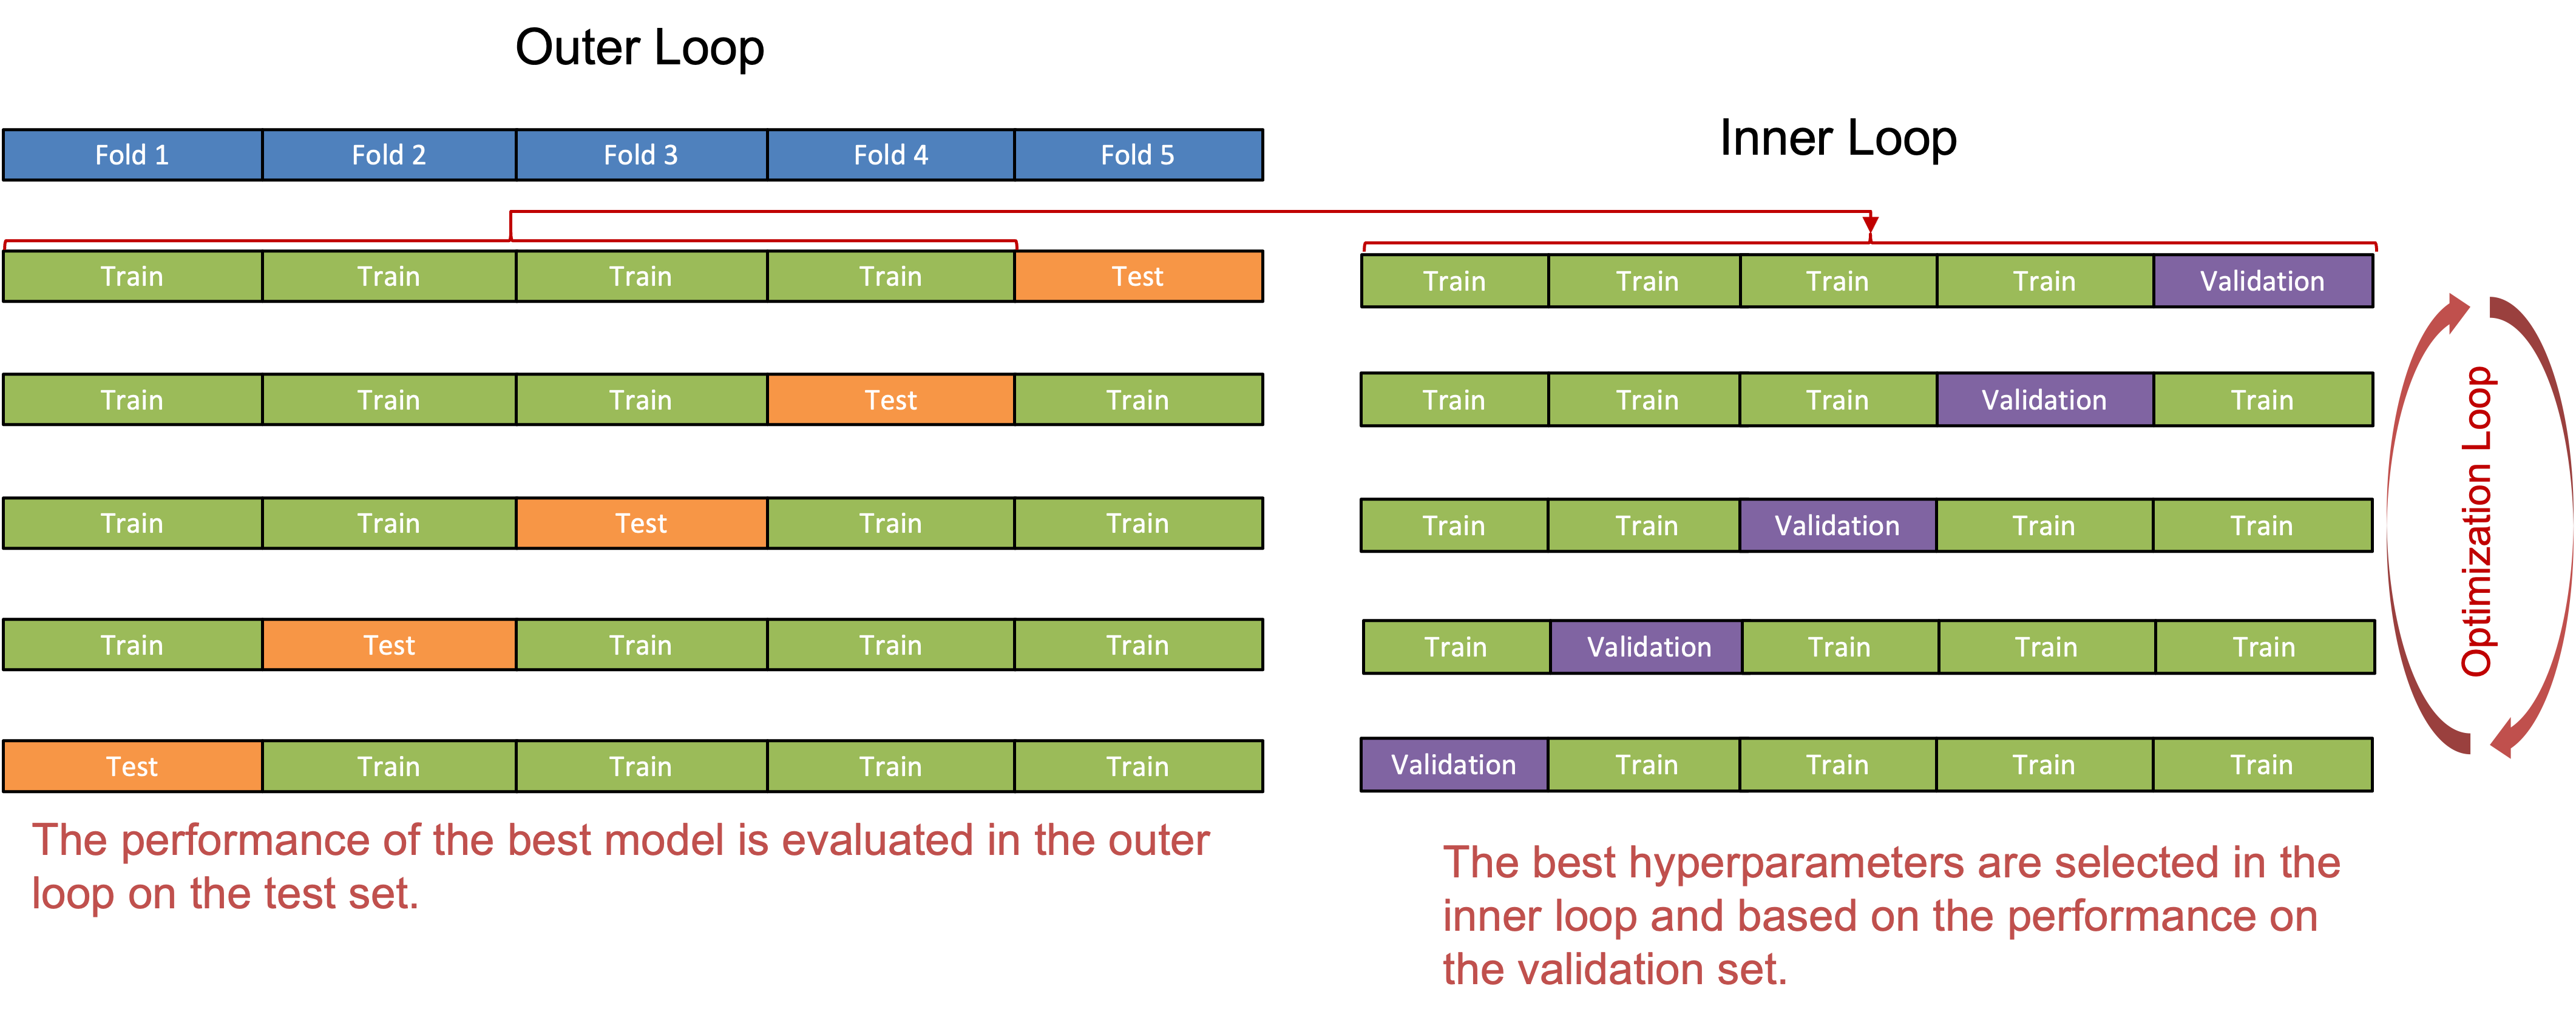

**Important Note:** We usually set the random seed to ensure the reproducibility of results.

**Important Note:** When setting the parameters grids, ensure the range of values always contain the default value. Always try some values below and above the defaults.

**Important Note:** Unless you use the exact hyperparameters from specific previously published reference (for more exact comparison), for a fair comparison and to avoid data leakage, all model hyperparameters must be decided in the optimization loop. This is also the case for the deep learning models. 

**Important Note:** It is recommended to use more than one metric for the evaluation of models.

In [ ]:
random_state = 42   # is set for the reproducibility of results 

outer_split_num = 5
inner_split_num = 5

# For illustrative purpose we use the minimal set of hyperparameters
models = {
    "Naive Bayes": {
        "model": GaussianNB(),
        "params": {
            # No hyperparameters for GaussianNB 
        }
    },
    "Logistic Regression": {
        "model": LogisticRegression(random_state=random_state),
        "params": {
            "model__C": [0.1, 1.0, 10.0],
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=random_state),
        "params": {
            "model__n_estimators": [50, 100, 200],
            "model__max_depth": [None, 5]
        }
    }
}

outer_cv = StratifiedKFold(n_splits=outer_split_num, shuffle=True, random_state=random_state)

# Inner CV: hyperparameter optimization
inner_cv = StratifiedKFold(n_splits=inner_split_num, shuffle=True, random_state=random_state)

In [ ]:
results = {}

for name, spec in models.items():
    
    # Build full pipeline based on type of classifiers
    if name == "Random Forest":
        pipeline = Pipeline(steps=[
            ("preprocessor", preprocessor_tree),
            ("model", spec["model"])
        ]) 
    else:    
        pipeline = Pipeline(steps=[
            ("preprocessor", preprocessor_non_tree),
            ("model", spec["model"])
        ])
        
    # Grid search (inner loop)
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=spec["params"],
        cv=inner_cv,
        scoring="roc_auc" # We can use only one metric for hyperparameter tuning. Be careful when choosing one.
    )
    
    # Nested CV (outer loop)
    cv_results = cross_validate(
        estimator=grid_search,
        X=X,
        y=y_binary,
        cv=outer_cv,
        scoring=["f1", "roc_auc","precision","recall"],
        return_estimator=True # this is useful for model diagnostic and explanation later.
    )
    
    results[name] = cv_results

    print(f"\n{name}")

    print(f"  F1-Score: {np.mean(results[name]['test_f1']):.3f} ± {np.std(results[name]['test_f1']):.3f}")
    print(f"  ROC-AUC:  {np.mean(results[name]['test_roc_auc']):.3f} ± {np.std(results[name]['test_roc_auc']):.3f}")
    print(f"  Precision: {np.mean(results[name]['test_precision']):.3f} ± {np.std(results[name]['test_precision']):.3f}")
    print(f"  Recall: {np.mean(results[name]['test_recall']):.3f} ± {np.std(results[name]['test_recall']):.3f}")

### 1.8.2 Common Pitfalls in Reporting the Results

**Pitfall 1:** Reporting only the mean performance across the outer loop. Always report the variability of metrics across outer loop. A good report in our example would be like:

$$
\begin{array}{lcccc}
\textbf{Model} & \textbf{F1-score} & \textbf{ROC-AUC} & \textbf{Precision} & \textbf{Recall} \\
\hline
\text{Naive Bayes} & \mathbf{0.698 \pm 0.032} & 0.812 \pm 0.027 & 0.675 \pm 0.029 & \mathbf{0.728 \pm 0.075} \\
\text{Logistic Regression} & 0.686 \pm 0.052 & \mathbf{0.837 \pm 0.032} & \mathbf{0.708 \pm 0.028} & 0.672 \pm 0.095 \\
\text{Random Forest} & 0.682 \pm 0.056 & 0.816 \pm 0.044 & 0.695 \pm 0.034 & 0.672 \pm 0.082 \\
\end{array}
$$

**Pitfall 2:** Misinterpreting the performance variability across the outer CV loop. Please note this variability reflects performance variation across cross-validation folds, not a formal confidence interval, and it does not a good estimation of variance of the model because the outer fold scores are not independent from each other.


**Pitfall 3:** Reporting the best hyperparameters for a model in nested K-Fold CV. When nested K-Fold is used, each outer fold sees different training data, Thus, the selected hyperparameters vary across outer folds. In nested cross-validation, hyperparameters are selected independently within each outer training fold. As a result, different folds may lead to different optimal hyperparameter configurations. Therefore, there is no single “best” hyperparameter set in nested CV. Any attempt to force one would reintroduce optimism or leakage. 

Instead, monitoring the variability of hyperparameters across folds provides insight into the stability and sensitivity of the model with respect to hyperparameter choices. Consistent selections across folds indicate robust configurations, whereas high variability suggests stronger dependence on the specific training data.

In [ ]:
best_model = "Logistic Regression"


best_params = [est.best_params_ for est in results[best_model]["estimator"]]

print(f"\n{best_model} – best hyperparameters per outer fold:")
for i, params in enumerate(best_params, 1):
    print(f"  Fold {i}: {params}")


We can use a bar plot to compare the accuracies across classifiers and report the results. Make sure your plot is revealing, clear, and informative (mind using colors and readable font size).

In [ ]:
# Models and metrics
models = ['Naive Bayes', 'Logistic Regression', 'Random Forest']
metrics = {
    'F1-score': 'test_f1',
    'ROC-AUC': 'test_roc_auc',
    'Precision': 'test_precision',
    'Recall': 'test_recall'
}

# Prepare data
means = {
    metric: [np.mean(results[m][key]) for m in models]
    for metric, key in metrics.items()
}
stds = {
    metric: [np.std(results[m][key]) for m in models]
    for metric, key in metrics.items()
}

# Colors
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(models)))

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (metric_name, _) in zip(axes, metrics.items()):
    
    bars = ax.bar(
        models,
        means[metric_name],
        yerr=stds[metric_name],
        capsize=6,
        color=colors,
        alpha=0.85
    )
    
    ax.set_title(metric_name, fontsize=14, fontweight='bold')
    ax.set_ylim(0.5, max(means[metric_name])+0.1)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    ax.tick_params(axis='x', labelrotation=25)
    ax.tick_params(axis='both', labelsize=11)
    
    # Remove spines for a cleaner look
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # Annotate bars
    for bar, mean in zip(bars, means[metric_name]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            mean - 0.1,
            f"{mean:.3f}",
            ha='center',
            va='bottom',
            fontsize=12,
            fontweight='bold'
        )

# Global title and layout
fig.suptitle(
    'Comparison of Classifier Performance',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('Classifier_comparison_multimetric.pdf', dpi=300)
plt.show()


A figure and its caption must be self-content. So always spend some time in writing a good caption for your figure that describes what is in the figure and a summary conclusion. For example for this figure we can add:

*"Figure 1. Comparison of classification performance across multiple evaluation metrics (F1-score, ROC-AUC, precision, and recall) for Naive Bayes, Logistic Regression, and Random Forest classifiers using nested cross-validation. Bars indicate mean performance across outer cross-validation folds, while error bars represent variability across folds, reflecting sensitivity to data splits. The figure highlights that model ranking depends on the chosen metric and that performance differences are small relative to cross-validation variability."*

### 1.8.3 Common Pitfalls in Interpreting the Results

**Common pitfall:** A common misinterpretation of model evaluation results is to select the model with the highest mean value of a single performance metric. For example, one might conclude that logistic regression performs best, since it achieves the highest mean ROC-AUC among the three benchmarked classifiers.

However, this conclusion is fragile and relies on several implicit assumptions. First, it assumes that ROC-AUC is the most relevant metric for the task at hand. If the evaluation criterion were instead the F1-score, Naive Bayes would appear to perform slightly better. Second, the observed differences between models are small relative to the variability across outer cross-validation folds. As a result, conclusions based solely on mean performance values may change if the random seed, number of folds, hyperparameter range, or data partitioning strategy is modified.

A more valid interpretation requires considering (i) the variability of performance across folds, (ii) the meaning and limitations of individual evaluation metrics, and (iii) the specific goals of the application.

From this perspective, the results suggest that all three models exhibit broadly comparable performance. Logistic regression consistently shows the highest ROC-AUC, indicating stronger ability to rank patients by risk and supporting its use for risk stratification. Naive Bayes achieves slightly higher recall and F1-score, suggesting greater sensitivity in identifying high-risk patients, albeit at the cost of lower precision. Random forests perform similarly but do not provide a clear advantage over the simpler models in this setting.

Now what would be the answer to RQ1?

Taken together, the results do not point to a single universally superior classifier. Instead, they highlight a set of trade-offs between discrimination, precision, and recall, as well as sensitivity to data splits. Consequently, the answer to RQ1 is not that one model is categorically “better” than the others, but that different models may be preferable depending on the evaluation metric and the intended use of the predictions. This emphasizes the importance of aligning model selection with application-specific requirements rather than relying on a single summary statistic.


## 1.9 Global Model Explanation and Feature Importance Analysis (RQ2)

Global model explanation aims to summarize how a trained machine learning model uses input features to make predictions across the entire dataset. Rather than explaining individual predictions, global explanations provide an overall picture of which features are most influential and how strongly they contribute to the model’s behavior on average.

To answer RQ2 (“Which clinical features contribute most strongly to the prediction of diabetes disease progression and risk stratification?”), global model explanations can be used to quantify the relative importance of clinical measurements in the trained model. Features with higher global importance are those that the model relies on more strongly when predicting disease progression or assigning risk.

There are in general two types of global model explanation methods:

1) Model-specific Global Explanations: that rely on the internal structure of a particular model class. Examples include regression coefficients in linear models or impurity-based feature importance in tree-based models. Examples are odds ratios in logistic regression and impurity feature importance in random forest. Model-specific explanations are easy to compute and interpret but are not directly comparable across different model classes.

2) Model-agnostic Global Explanations: Model-agnostic methods estimate feature importance by measuring how much model performance degrades when the relationship between a feature and the target is disrupted. Because they do not depend on model internals, they enable fair comparison across different model types. Permutation importance is a model-agnostic global explanation method that quantifies how much a model’s performance decreases when the values of a single feature are randomly permuted. Larger drops in performance indicate greater feature importance.


**Common Pitfall:** Global feature importance should be interpreted as reflecting predictive relevance rather than causal influence. Features may appear important due to correlations with other variables, and importance values depend on the trained model, preprocessing steps, and evaluation metric.

In this tutorial, global feature influence is assessed using model-specific explanations. For logistic regression, we use absolute magnitude of coefficients as a measure for feature importance. For random forests, impurity-based feature importance is used to quantify how much each feature contributes to reducing node impurity across the ensemble. For Gaussian Naive Bayes, feature relevance is summarized by the standardized difference between class-conditional feature distributions, reflecting how strongly a feature separates high- and low-risk groups under the model assumptions.

**Important Note:** Rather than fitting a single final model, feature importance is computed separately for each outer cross-validation fold and subsequently aggregated. This approach accounts for variability due to data splitting and hyperparameter selection, and provides a more robust estimate of which clinical features consistently contribute to model predictions.

**Important Note:** Calculating feature importance maps for one-hot-encoded categorical features could be tricky. 

In [ ]:
def get_transformed_feature_names(preprocessor):
    return preprocessor.get_feature_names_out()


def collapse_onehot_mean(df):
    """
    Collapse one-hot encoded features by mean importance.

    Expects a DataFrame with columns:
        - feature (transformed feature name)
        - importance
    Returns:
        pd.Series indexed by base feature name
    """
    df = df.copy()
    df["base_feature"] = (
        df["feature"]
        .str.replace(r"^(num__|cat__)", "", regex=True)
        .str.split("_")
        .str[0]
    )
    return df.groupby("base_feature")["importance"].mean()

def lr_importance(pipe):
    lr = pipe.named_steps["model"]
    pre = pipe.named_steps["preprocessor"]

    return pd.DataFrame({
        "feature": get_transformed_feature_names(pre),
        "importance": np.abs(lr.coef_.ravel())  # |log-odds|
    })

def rf_importance(pipe):
    rf = pipe.named_steps["model"]
    pre = pipe.named_steps["preprocessor"]

    return pd.DataFrame({
        "feature": get_transformed_feature_names(pre),
        "importance": rf.feature_importances_
    })

def gnb_importance(pipe):
    # Fisher score for Gaussian Naive Bayes
    nb = pipe.named_steps["model"]
    pre = pipe.named_steps["preprocessor"]

    mu0, mu1 = nb.theta_ # mean for each class and feature
    var0, var1 = nb.var_ # variance for each class and feature
    pooled_std = np.sqrt((var0 + var1) / 2)

    d = (mu1 - mu0) / pooled_std    # effect size as importance measure

    return pd.DataFrame({
        "feature": get_transformed_feature_names(pre),
        "importance": np.abs(d)
    })

def importance_across_folds(results, model_name, importance_fn):
    """
    Generic function to compute fold-level collapsed feature importance.

    Parameters
    ----------
    results : dict
        Output of cross_validate(..., return_estimator=True)
    model_name : str
        Key in results dict
    importance_fn : callable
        Function that takes a fitted pipeline and returns a DataFrame
        with columns ['feature', 'importance']

    Returns
    -------
    List[pd.Series]
        One Series per outer fold, indexed by base feature name
    """
    fold_importances = []

    for grid in results[model_name]["estimator"]:
        pipe = grid.best_estimator_

        df = importance_fn(pipe)
        collapsed = collapse_onehot_mean(df)

        fold_importances.append(collapsed)

    return fold_importances

def aggregate_importances(importances):
    combined = pd.concat(importances, axis=1)
    return pd.DataFrame({
        "importance_mean": combined.mean(axis=1),
        "importance_std": combined.std(axis=1, ddof=1)
    }).sort_values("importance_mean", ascending=False)


def plot_feature_importances_subplots(
    importance_dict,
    top_k=10,
    figsize=(16, 10)
):
    """
    Plot feature importances (mean ± std across folds) for multiple models
    using subplots.

    Parameters
    ----------
    importance_dict : dict
        Keys = model names
        Values = DataFrames with columns ['importance_mean', 'importance_std']
    top_k : int
        Number of top features to plot per model
    """
    n_models = len(importance_dict)
    fig, axes = plt.subplots(1, n_models, figsize=figsize, sharex=False)

    if n_models == 1:
        axes = [axes]

    for ax, (model_name, df) in zip(axes, importance_dict.items()):
        df_plot = df.head(top_k).iloc[::-1]  # reverse for horizontal bars

        bars = ax.barh(
            df_plot.index,
            df_plot["importance_mean"],
            xerr=df_plot["importance_std"],
            color="steelblue",
            alpha=0.85,
            capsize=5
        )

        ax.set_title(model_name, fontsize=14, fontweight="bold")
        ax.set_xlabel("Mean importance", fontsize=12)
        ax.set_ylabel("")

        ax.grid(axis="x", linestyle="--", alpha=0.6)
        ax.tick_params(axis="both", labelsize=11)

        # Remove spines
        for spine in ax.spines.values():
            spine.set_visible(False)

    fig.suptitle(
        "Global Feature Importance Across Models\n"
        "(Mean ± variability across outer cross-validation folds)",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig("Feature_importances_subplots.pdf", dpi=300)
    plt.show()


In [ ]:
lr_fold_importances = importance_across_folds(
    results, "Logistic Regression", lr_importance
)

rf_fold_importances = importance_across_folds(
    results, "Random Forest", rf_importance
)

nb_fold_importances = importance_across_folds(
    results, "Naive Bayes", gnb_importance
)

importance_dict = {
    "Logistic Regression": aggregate_importances(lr_fold_importances),
    "Random Forest": aggregate_importances(rf_fold_importances),
    "Naive Bayes": aggregate_importances(nb_fold_importances)
}

plot_feature_importances_subplots(
    importance_dict,
    top_k=10
)


## 1.9 Error Analysis in Sensitive Subgroups (RQ3)

Machine learning models are typically evaluated using aggregate performance metrics computed over the entire dataset. While this provides a useful overall summary, it can obscure systematic differences in model behavior across patient subgroups. For exmaple, in healthcare applications, such differences are particularly important when they involve sensitive attributes such as sex, age, or ethnicity, because uneven performance may lead to unequal quality of care. A model with high overall accuracy may still exhibit lower recall for one subgroup, meaning that high-risk patients in that group are more likely to be missed. Such disparities can arise even when sensitive attributes are not explicitly used by the model, due to correlations with other features or differences in data distribution.

To address this, a basic fairness audit can be performed by evaluating model performance separately for predefined subgroups. While this does not establish causality or fully resolve fairness concerns, it helps identify whether potential biases exist and whether further investigation or mitigation strategies are warranted.

In this tutorial, we assess subgroup performance by computing standard evaluation metrics separately for male and female patients, using the same cross-validation framework as in the main model evaluation. This allows us to examine whether predictive performance differs systematically across sex, indicating potential fairness concerns.

In [ ]:
def subgroup_performance_analysis(
    results,
    model_name,
    X,
    y,
    subgroup_col="sex",
    min_group_size=5
):
    """
    Compute subgroup-specific performance metrics (mean ± std across outer CV folds)
    using fitted estimators stored in nested cross-validation results.

    Parameters
    ----------
    results : dict
        Output of cross_validate(..., return_estimator=True)
    model_name : str
        Key of the model in results
    X : pd.DataFrame
        Feature matrix
    y : pd.Series
        Binary target
    subgroup_col : str
        Column name used for subgrouping (e.g., 'sex')
    min_group_size : int
        Minimum number of samples required per subgroup in a fold

    Returns
    -------
    pd.DataFrame
        Multi-index DataFrame with rows (subgroup, metric)
        and columns (mean, std)
    """
    records = []
    estimators = results[model_name]["estimator"]

    for (train_idx, test_idx), grid in zip(outer_cv.split(X, y), estimators):
        pipe = grid.best_estimator_

        X_test = X.iloc[test_idx]
        y_test = y.iloc[test_idx]

        y_pred = pipe.predict(X_test)
        y_proba = pipe.predict_proba(X_test)[:, 1]

        for subgroup in X_test[subgroup_col].unique():
            mask = X_test[subgroup_col] == subgroup

            if mask.sum() < min_group_size:
                continue

            records.append({
                "subgroup": subgroup,
                "roc_auc": roc_auc_score(y_test[mask], y_proba[mask]),
                "f1": f1_score(y_test[mask], y_pred[mask]),
                "precision": precision_score(y_test[mask], y_pred[mask]),
                "recall": recall_score(y_test[mask], y_pred[mask])
            })

    df = pd.DataFrame(records)

    summary = (
        df
        .groupby("subgroup")
        .agg(["mean", "std"])
        .round(3)
    )

    return summary


In [ ]:
lr_sex_fairness = subgroup_performance_analysis(
    results=results,
    model_name="Logistic Regression",
    X=X,
    y=y_binary,
    subgroup_col="sex"
)

lr_sex_fairness

In [ ]:
# Metrics to plot
metrics = lr_sex_fairness.columns.levels[0].to_list()

# Extract values from the dataframe
male_mean   = [lr_sex_fairness.loc[1.0, (m, "mean")] for m in metrics]
male_std    = [lr_sex_fairness.loc[1.0, (m, "std")]  for m in metrics]

female_mean = [lr_sex_fairness.loc[2.0, (m, "mean")] for m in metrics]
female_std  = [lr_sex_fairness.loc[2.0, (m, "std")]  for m in metrics]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

bars1 = plt.bar(
    x - width/2,
    male_mean,
    width,
    yerr=male_std,
    capsize=6,
    alpha=0.85,
    label="Female"
)

bars2 = plt.bar(
    x + width/2,
    female_mean,
    width,
    yerr=female_std,
    capsize=6,
    alpha=0.85,
    label="Male"
)

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.ylim(0.25, 0.95)
plt.xlabel("Metrics", fontsize=14, fontweight="bold")
plt.ylabel("Score", fontsize=14, fontweight="bold")
plt.title(
    "Subgroup Performance Comparison by Sex\n"
    "(Mean ± fold variability)",
    fontsize=16,
    fontweight="bold"
)

plt.xticks(x, metrics, fontsize=12)
plt.yticks(fontsize=12)

# Remove spines
for spine in plt.gca().spines.values():
    spine.set_visible(False)

# Annotate bars with mean values
for bars, means in [(bars1, male_mean), (bars2, female_mean)]:
    for bar, mean in zip(bars, means):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            0.5,
            f"{mean:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            c='white'
        )

plt.legend()
plt.tight_layout()
plt.show()


The model exhibits consistently higher performance for the male subgroup across all evaluated metrics. In particular, recall and F1-score are substantially lower for female patients, indicating that high-risk female cases are more likely to be missed. Differences in ROC-AUC further suggest that risk ranking is less accurate for females. Although variability across cross-validation folds is non-negligible, the systematic nature of these differences highlights a potential fairness concern that merits further investigation, such as calibration analysis or subgroup-specific error inspection (for example using confusion matrices).


<div style="
    display: flex;
    align-items: center;
    justify-content: flex-end;
    gap: 8px;
    font-size: 9px;
    color: #888;
    font-style: italic;
    margin-top: 30px;
">
    <span> © 2026 S.M. Kia (Tilburg University) — Licensed under the Creative Commons Attribution 4.0 International (CC BY 4.0). This notebook is provided for educational purposes. Redistribution and reuse are permitted with proper attribution.</span>
</div>
